In [2]:
%matplotlib inline
# %matplotlib notebook
from sklearn.model_selection import train_test_split
import numpy as np
import qutip as qt
from entVAE import vae_utils 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1779101248.926559   40929 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779101248.955497   40929 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779101250.120865   40929 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

In [4]:
n_angle = 101
n_samples = 1000
scan_arr = np.linspace(0, np.pi, n_angle)
alpha_arr = np.zeros(101000)
cnt = 0
for theta in scan_arr:
        for _ in (range(n_samples)):
            alpha_arr[cnt] = theta
            cnt += 1

In [5]:
colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
markers = ["o", "s", "^", "D", "v", "p"]

MS = 5 
LW = 1.2 
MW = 0.5

# Noisy Dataset  $0.75\beta$

Load Dataset

In [6]:
rho_arr_noisy = np.load('../data/unitary_4x4_101_1000.npy', mmap_mode="r")
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(rho_arr_noisy, alpha_arr, random_state=42)
concurrence_noisy_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noisy])

Load trained VAE and define Hyperparameters:

In [7]:
batch_size = 64
beta = 0.75
learning_rate = 0.0001
lat_dim = 1
hidden_act = "tanh"
final_act = "linear"

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, hidden_act, final_act)
encoder.load_weights("../data/encoder_noise_075beta.h5")
decoder.load_weights("../data/decoder_noise_075beta.h5")

vae_noisy = vae_utils.VAE(encoder, decoder, beta)
vae_noisy.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

z_mean_noisy, z_log_var_noisy, z_noisy = vae_noisy.encoder.predict(X_test_noisy)

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step


In [8]:
gamma = np.load('../data/gamma_new.npy', mmap_mode="r")[:76]
rho_gamma = np.load('../data/rho_gamma_noiseless.npy', mmap_mode="r")[:76]
conc_gamma_arr = np.array([qt.concurrence(qt.Qobj(np.reshape(dm,(4,4)),dims=[[2,2],[2,2]])) for dm in rho_gamma])

gamma_10 = np.repeat(gamma,10)
rho_gamma_10 = np.repeat(rho_gamma,10,axis=0)
conc_gamma_arr_10 = np.repeat(conc_gamma_arr,10)

z_mean_gamma, _, _ = vae_noisy.encoder.predict(rho_gamma)
z_mean_gamma_10, _, _ = vae_noisy.encoder.predict(rho_gamma_10)

gamma_10 = np.reshape(gamma_10,(76,10))
z_mean_gamma_10 = np.reshape(z_mean_gamma_10,(76,10))
conc_gamma_arr_10 = np.reshape(conc_gamma_arr_10,(76,10))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step


In [9]:
def scale_dataset(dataset):
    min_value = np.min(dataset)
    max_value = np.max(dataset)
    min_range = -0.5
    max_range = 1

    scaled_dataset = (dataset - min_value) / (max_value - min_value) * (max_range - min_range) + min_range
    return scaled_dataset

scaled_data = scale_dataset(z_mean_gamma)

In [10]:
def c_test(rho):
    sysy = qt.tensor(qt.sigmay(), qt.sigmay())
    rho_tilde = (rho * sysy) * (rho.conj() * sysy)
    evals = rho_tilde.eigenenergies()
    evals = abs(np.sort(np.real(evals)))
    lsum = np.sqrt(evals[3]) - np.sqrt(evals[2]) - np.sqrt(evals[1]) - np.sqrt(evals[0])

    return lsum

def c_raw(rho):
    sysy = qt.tensor(qt.sigmay(), qt.sigmay())
    rho_spinflip = sysy * rho.conj() * sysy
    R = rho * rho_spinflip
    evals = np.sort(np.real(R.eigenenergies()))
    return np.sqrt(evals[3]) - np.sqrt(evals[2]) - np.sqrt(evals[1]) - np.sqrt(evals[0])

test_c = np.array([c_test(qt.Qobj(np.reshape(dm,(4,4)),dims=[[2,2],[2,2]])) for dm in rho_gamma])
test_raw = np.array([c_raw(qt.Qobj(np.reshape(dm,(4,4)),dims=[[2,2],[2,2]])) for dm in rho_gamma])

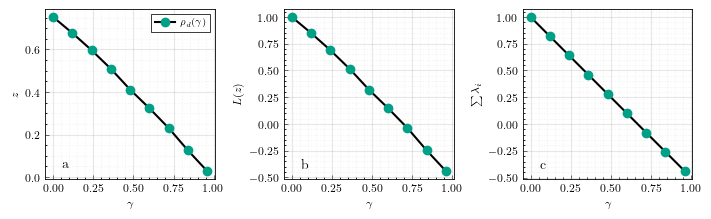

In [11]:
fig, ax = plt.subplots(
    1, 3,
    figsize=(7.0, 2.4),
    constrained_layout=True
)

ax[0].plot(gamma[::9],z_mean_gamma[::9] ,"-o", c='black', mfc=colors[2],  mec=colors[2],label="$\\rho_d(\\gamma)$")


ax[1].plot(gamma[::9],scaled_data[::9] ,"-o", c='black', mfc=colors[2], mec=colors[2],label="L(z)")


ax[2].plot(gamma[::9],test_c[::9] ,"-o", c='black', mfc=colors[2], mec=colors[2],label="L(z)")

ax[0].set_ylabel("$z$")
ax[1].set_ylabel("$L(z)$")
ax[2].set_ylabel("$\\sum \\lambda_i$")



ax[0].set_xlabel("$\\gamma$")
ax[1].set_xlabel("$\\gamma$")
ax[2].set_xlabel("$\\gamma$")



ax[0].text(
        0.1, 0.05,  # x=95% right, y=5% from bottom (in axes coords)
        "a",
        transform=ax[0].transAxes,
        va='bottom',
        ha='left',
        fontsize=10
    )

ax[1].text(
        0.1, 0.05,  # x=95% right, y=5% from bottom (in axes coords)
        "b",
        transform=ax[1].transAxes,
        va='bottom',
        ha='left',
        fontsize=10
    )

ax[2].text(
        0.1, 0.05,  # x=95% right, y=5% from bottom (in axes coords)
        "c",
        transform=ax[2].transAxes,
        va='bottom',
        ha='left',
        fontsize=10
    )


for a in ax:
    # a.grid(alpha=0.3)
    a.set_box_aspect(1)
    a.grid(True, which="major", linestyle="-", alpha=0.3)
    a.grid(True, which="minor", linestyle=":", alpha=0.15)

    a.tick_params(direction="in", which="both", labelsize=8)
    a.tick_params(which="major", length=3)
    a.tick_params(which="minor", length=1.5)
    a.minorticks_on()

legend = ax[0].legend(
    frameon=True,
    loc="best",
    fontsize=7,
    ncol=1,
    columnspacing=1.0,
    handletextpad=0.5,
    framealpha=0.9,
    edgecolor="black",
    fancybox=False,
    )
legend.get_frame().set_linewidth(0.6)

# plt.savefig("fig_depol_appx.pdf",bbox_inches="tight",pad_inches=0.1)

In [20]:
gamma = np.load('../data/gamma_new.npy', mmap_mode="r")[:76]
rho_gamma = np.load('../data/rho_gamma_noiseless.npy', mmap_mode="r")[:76]
conc_gamma_arr = np.array([qt.concurrence(qt.Qobj(np.reshape(dm,(4,4)),dims=[[2,2],[2,2]])) for dm in rho_gamma])

gamma_10 = np.repeat(gamma,10)
rho_gamma_10 = np.repeat(rho_gamma,10,axis=0)
conc_gamma_arr_10 = np.repeat(conc_gamma_arr,10)

z_mean_gamma, _, _ = vae_noisy.encoder.predict(rho_gamma)
z_mean_gamma_10, _, _ = vae_noisy.encoder.predict(rho_gamma_10)

gamma_10 = np.reshape(gamma_10,(76,10))
z_mean_gamma_10 = np.reshape(z_mean_gamma_10,(76,10))
conc_gamma_arr_10 = np.reshape(conc_gamma_arr_10,(76,10))


# Werner-state dataset generated with QuTiP for gamma in [0, 1]
gamma_small = np.linspace(0.0, 1, 21)

# Bell state |Phi+> = (|00> + |11>)/sqrt(2)
phi_plus = (qt.tensor(qt.basis(2, 0), qt.basis(2, 0)) + qt.tensor(qt.basis(2, 1), qt.basis(2, 1))).unit()
rho_pi = qt.ket2dm(phi_plus)

# Two-qubit maximally mixed state I/4
id4 = qt.qeye([2, 2])

# rho_d(gamma) = (1-gamma) * rho_pi + (gamma/4) * I
rho_werner_qobj = [(1.0 - g) * rho_pi + (g / 4.0) * id4 for g in gamma_small]

# Flatten to length-16 vectors to match model input convention used in this notebook
rho_werner_flat = np.array([rho.full().reshape(-1) for rho in rho_werner_qobj])

# Concurrence of each state
conc_werner = np.array([qt.concurrence(rho) for rho in rho_werner_qobj])

print('gamma_small:', gamma_small)
print('rho_werner_flat shape:', rho_werner_flat.shape)
print('conc_werner:', conc_werner)

z_mean_gamma, _, _ = vae_noisy.encoder.predict(rho_werner_flat)

def linear_fit(x, y):
    arr_len = int(len(x)/10)
    fit_obj = np.polyfit(x, y, 1)
    fit_pred = np.poly1d(fit_obj)
    return np.reshape(fit_pred(x), (arr_len, 10)), fit_pred

# conc_werner vs z_mean_gamma 
fit_obj = np.polyfit(conc_werner.flatten(), z_mean_gamma.flatten(), 1)
fit_pred = np.poly1d(fit_obj)

# 2. Generate predictions (Pass the X variable here!)
y_gamma_fit = fit_pred(conc_werner.flatten())

def c_test(rho):
    sysy = qt.tensor(qt.sigmay(), qt.sigmay())
    rho_tilde = (rho * sysy) * (rho.conj() * sysy)
    evals = rho_tilde.eigenenergies()
    evals = abs(np.sort(np.real(evals)))
    lsum = np.sqrt(evals[3]) - np.sqrt(evals[2]) - np.sqrt(evals[1]) - np.sqrt(evals[0])

    return lsum

test_c = np.array([c_test(dm) for dm in rho_werner_qobj])


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
gamma_small: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
rho_werner_flat shape: (21, 16)
conc_werner: [1.    0.925 0.85  0.775 0.7   0.625 0.55  0.475 0.4   0.325 0.25  0.175
 0.1   0.025 0.    0.    0.    0.    0.    0.    0.   ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


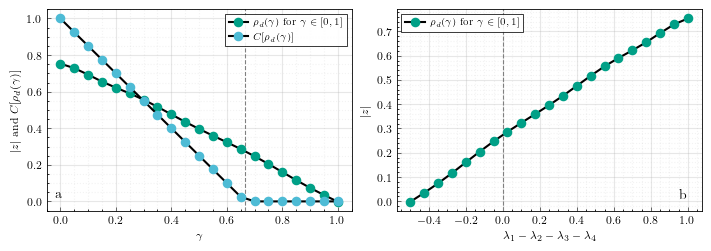

In [21]:
#HERHEE

fig,ax = plt.subplots(1,2, figsize=(7.0, 2.4), constrained_layout=True)

ax[0].plot(
        gamma_small,
        z_mean_gamma,
        "-o",
        c='black', mfc=colors[2],  mec=colors[2],
        label="$\\rho_d(\\gamma)$ for $\\gamma \\in [0, 1]$",
        markersize=6,
        markeredgewidth=0.9,
        zorder=3
    )

ax[0].plot(
        gamma_small,
        conc_werner,
        "-o",
        c='black', mfc=colors[1],  mec=colors[1],
        label="$C[\\rho_d(\\gamma)]$",
        markersize=6,
        markeredgewidth=0.9,
        zorder=3
    )

ax[1].plot(
        test_c,
        z_mean_gamma,
        "-o",
        c='black', mfc=colors[2],  mec=colors[2],
        label="$\\rho_d(\\gamma)$ for $\\gamma \\in [0, 1]$",
        markersize=6,
        markeredgewidth=0.9,
        zorder=3
    )


ax[0].axvline(2/3, color='gray', linestyle='--', linewidth=0.8)
ax[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)

ax[0].set_ylabel("$|z|$ and $C[\\rho_d(\\gamma)]$")

ax[1].set_ylabel("$|z|$")

ax[0].set_xlabel("$\\gamma$")
ax[1].set_xlabel("$\\lambda_1-\\lambda_2-\\lambda_3-\\lambda_4$")

ax[0].text(
        0.05, 0.05,  # x=95% right, y=5% from bottom (in axes coords)
        "a",
        transform=ax[0].transAxes,
        va='bottom',
        ha='right',
        fontsize=10
    )

ax[1].text(
        0.95, 0.05,  # x=95% right, y=5% from bottom (in axes coords)
        "b",
        transform=ax[1].transAxes,
        va='bottom',
        ha='right',
        fontsize=10
    )


legend = ax[0].legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=1,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
legend.get_frame().set_linewidth(0.6)

legend = ax[1].legend(
        frameon=True,
        loc="upper left",
        fontsize=7,
        ncol=1,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
legend.get_frame().set_linewidth(0.6)

for a in ax:

    a.grid(True, which="major", linestyle="-", alpha=0.3)
    a.grid(True, which="minor", linestyle=":", alpha=0.15)

    a.tick_params(direction="in", which="both", labelsize=8)
    a.tick_params(which="major", length=3)
    a.tick_params(which="minor", length=1.5)
    a.minorticks_on()

# plt.tight_layout()

# plt.savefig("fig_exp7_new.pdf",bbox_inches="tight",pad_inches=0.1)
#HERHEE